<a href="https://colab.research.google.com/github/prakharshukla2007cuet-spec/DSML-Module-1/blob/main/Covid_19_India_DSML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 in India: State-wise Analysis

**Dataset:** [COVID-19 in India](https://www.kaggle.com/datasets/sudalairajkumar/covid19-in-india) (Kaggle, `covid_19_india.csv`), covering 30 Jan 2020 to 11 Aug 2021.

**What this notebook does**
1. Loads and inspects the data
2. Cleans it (inconsistent state names, non-state rows, duplicates)
3. Builds a state-level summary from each state's **latest** record
4. Visualises the top states, case/fatality/recovery rates and the national trend

> **Note:** the case, death and recovery columns are *cumulative* totals, so state summaries use the latest reported row per state, and daily numbers are derived by differencing.

## 1. Setup

In [18]:
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.options.display.float_format = "{:,.2f}".format

## 2. Load the data

In [19]:
# Download via kagglehub (works in Colab / with Kaggle credentials).
# Fall back to a local copy of the CSV if the download is unavailable.
try:
    import kagglehub
    path = kagglehub.dataset_download("sudalairajkumar/covid19-in-india")
except Exception as exc:
    print(f"kagglehub download failed ({exc}); looking for a local copy instead.")
    path = "."

print("Dataset path:", path)
print("Files:", [f for f in os.listdir(path) if f.endswith(".csv")])

df = pd.read_csv(os.path.join(path, "covid_19_india.csv"))
df.head()

Using Colab cache for faster access to the 'covid19-in-india' dataset.
Dataset path: /kaggle/input/covid19-in-india
Files: ['StatewiseTestingDetails.csv', 'covid_vaccine_statewise.csv', 'covid_19_india.csv']


,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3


## 3. Initial inspection

In [20]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")
df.info()

Shape: 18,110 rows x 9 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB


In [21]:
print("Missing values per column:")
print(df.isnull().sum(), "\n")
print("Fully duplicated rows:", df.duplicated().sum())

Missing values per column:
Sno                         0
Date                        0
Time                        0
State/UnionTerritory        0
ConfirmedIndianNational     0
ConfirmedForeignNational    0
Cured                       0
Deaths                      0
Confirmed                   0
dtype: int64 

Fully duplicated rows: 0


## 4. Data cleaning

Problems found in the raw data:

| Issue | Example | Fix |
|---|---|---|
| Footnote markers appended to names | `Maharashtra***`, `Telangana***` | strip `*` and `#` |
| Spelling variants | `Karanataka`, `Telengana` | map to standard names |
| Non-state placeholder rows | `Unassigned`, `Cases being reassigned to states` | drop |
| Placeholder `-` in nationality columns | `ConfirmedIndianNational` | dropped (not used, mostly empty after early 2020) |

In [22]:
df = df.drop_duplicates().copy()
df["Date"] = pd.to_datetime(df["Date"])

# Standardise state / UT names
df["State"] = (
    df["State/UnionTerritory"]
    .str.replace(r"[*#]+", "", regex=True)
    .str.strip()
    .replace({
        "Karanataka": "Karnataka",
        "Telengana": "Telangana",
        "Dadra and Nagar Haveli": "Dadra and Nagar Haveli and Daman and Diu",
        "Daman & Diu": "Dadra and Nagar Haveli and Daman and Diu",
    })
)

# Drop rows that are not real states / UTs
non_states = ["Unassigned", "Cases being reassigned to states"]
df = df[~df["State"].isin(non_states)]

# Rename for clarity and drop columns we do not use
df = df.rename(columns={"Cured": "Recovered"})
df = df.drop(columns=["Sno", "Time", "State/UnionTerritory",
                      "ConfirmedIndianNational", "ConfirmedForeignNational"])

# One record per state per day (keep the last if the rename created overlaps)
df = (df.sort_values(["State", "Date"])
        .drop_duplicates(["State", "Date"], keep="last")
        .reset_index(drop=True))

# Active cases = Confirmed - Deaths - Recovered (cannot be negative)
df["Active"] = (df["Confirmed"] - df["Deaths"] - df["Recovered"]).clip(lower=0)

print(f"Clean data: {df.shape[0]:,} rows | {df['State'].nunique()} states/UTs")
print(f"Date range: {df['Date'].min():%d %b %Y} to {df['Date'].max():%d %b %Y}")
df.tail()

Clean data: 18,046 rows | 37 states/UTs
Date range: 30 Jan 2020 to 11 Aug 2021


,Date,Recovered,Deaths,Confirmed,State,Active
18041,2021-08-07,1503535,18202,1532379,West Bengal,10642
18042,2021-08-08,1504326,18217,1533128,West Bengal,10585
18043,2021-08-09,1505089,18229,1533803,West Bengal,10485
18044,2021-08-10,1505808,18240,1534360,West Bengal,10312
18045,2021-08-11,1506532,18252,1534999,West Bengal,10215


In [23]:
# Sanity check: confirm no leftover name variants
sorted(df["State"].unique())

['Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra and Nagar Haveli and Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Himanchal Pradesh',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Ladakh',
 'Lakshadweep',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

## 5. State-level summary

Because the columns are cumulative, we take each state's **latest** record. (Taking `.max()` of every column separately, as before, would mix values from different dates; e.g. *Active* would show the historical peak rather than the current value.)

In [24]:
latest = df.loc[df.groupby("State")["Date"].idxmax()]

state_data = latest[["State", "Confirmed", "Deaths", "Recovered", "Active"]].copy()
confirmed = state_data["Confirmed"].where(state_data["Confirmed"] > 0)   # avoid divide-by-zero

state_data["Recovery_Rate"] = (state_data["Recovered"] / confirmed * 100).round(2)
state_data["Death_Rate"]    = (state_data["Deaths"]    / confirmed * 100).round(2)
state_data = state_data.reset_index(drop=True)

state_data.sort_values("Confirmed", ascending=False).reset_index(drop=True)

,State,Confirmed,Deaths,Recovered,Active,Recovery_Rate,Death_Rate
0,Maharashtra,6363442,134201,6159676,69565,96.80,2.11
1,Kerala,3586693,18004,3396184,172505,94.69,0.50
2,Karnataka,2921049,36848,2861499,22702,97.96,1.26
3,Tamil Nadu,2579130,34367,2524400,20363,97.88,1.33
4,Andhra Pradesh,1985182,13564,1952736,18882,98.37,0.68
5,Uttar Pradesh,1708812,22775,1685492,545,98.64,1.33
6,West Bengal,1534999,18252,1506532,10215,98.15,1.19
7,Delhi,1436852,25068,1411280,504,98.22,1.74
8,Chhattisgarh,1003356,13544,988189,1623,98.49,1.35
9,Odisha,988997,6565,972710,9722,98.35,0.66


## 6. Top 10 states by confirmed cases

In [25]:
top10 = (state_data.nlargest(10, "Confirmed")
         .reset_index(drop=True))
top10

,State,Confirmed,Deaths,Recovered,Active,Recovery_Rate,Death_Rate
0,Maharashtra,6363442,134201,6159676,69565,96.80,2.11
1,Kerala,3586693,18004,3396184,172505,94.69,0.50
2,Karnataka,2921049,36848,2861499,22702,97.96,1.26
3,Tamil Nadu,2579130,34367,2524400,20363,97.88,1.33
4,Andhra Pradesh,1985182,13564,1952736,18882,98.37,0.68
5,Uttar Pradesh,1708812,22775,1685492,545,98.64,1.33
6,West Bengal,1534999,18252,1506532,10215,98.15,1.19
7,Delhi,1436852,25068,1411280,504,98.22,1.74
8,Chhattisgarh,1003356,13544,988189,1623,98.49,1.35
9,Odisha,988997,6565,972710,9722,98.35,0.66


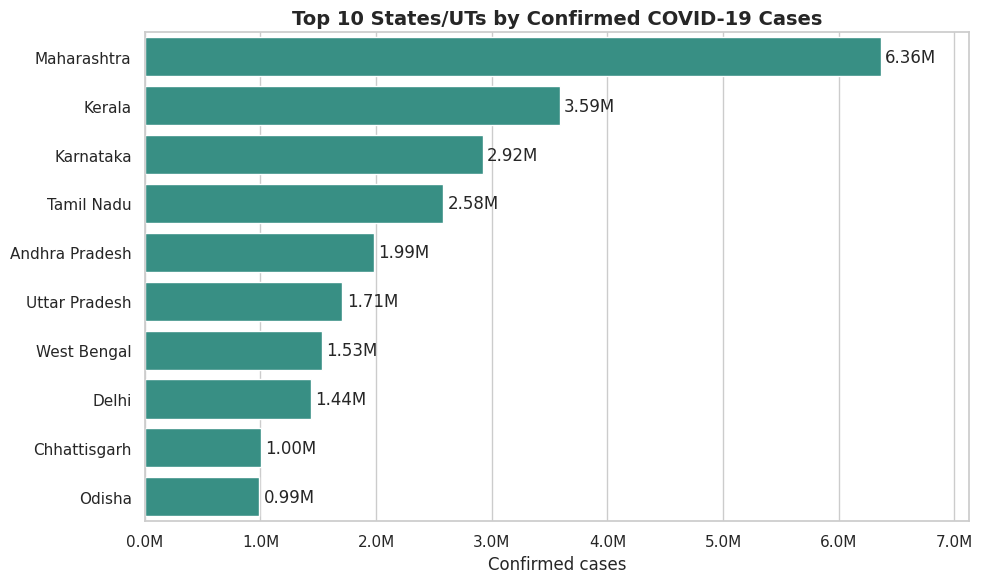

In [26]:
def millions_fmt(x, _):
    return f"{x/1e6:.1f}M"

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top10, y="State", x="Confirmed", color="#2a9d8f", ax=ax)

ax.set_title("Top 10 States/UTs by Confirmed COVID-19 Cases", fontsize=14, weight="bold")
ax.set_xlabel("Confirmed cases")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(millions_fmt))
for c in ax.containers:
    ax.bar_label(c, labels=[f"{v/1e6:.2f}M" for v in top10["Confirmed"]], padding=3)
ax.set_xlim(0, top10["Confirmed"].max() * 1.12)

plt.tight_layout()
plt.show()

## 7. Top 10 states by deaths

In [27]:
top_deaths = state_data.nlargest(10, "Deaths").reset_index(drop=True)
top_deaths

,State,Confirmed,Deaths,Recovered,Active,Recovery_Rate,Death_Rate
0,Maharashtra,6363442,134201,6159676,69565,96.80,2.11
1,Karnataka,2921049,36848,2861499,22702,97.96,1.26
2,Tamil Nadu,2579130,34367,2524400,20363,97.88,1.33
3,Delhi,1436852,25068,1411280,504,98.22,1.74
4,Uttar Pradesh,1708812,22775,1685492,545,98.64,1.33
5,West Bengal,1534999,18252,1506532,10215,98.15,1.19
6,Kerala,3586693,18004,3396184,172505,94.69,0.50
7,Punjab,599573,16322,582791,460,97.20,2.72
8,Andhra Pradesh,1985182,13564,1952736,18882,98.37,0.68
9,Chhattisgarh,1003356,13544,988189,1623,98.49,1.35


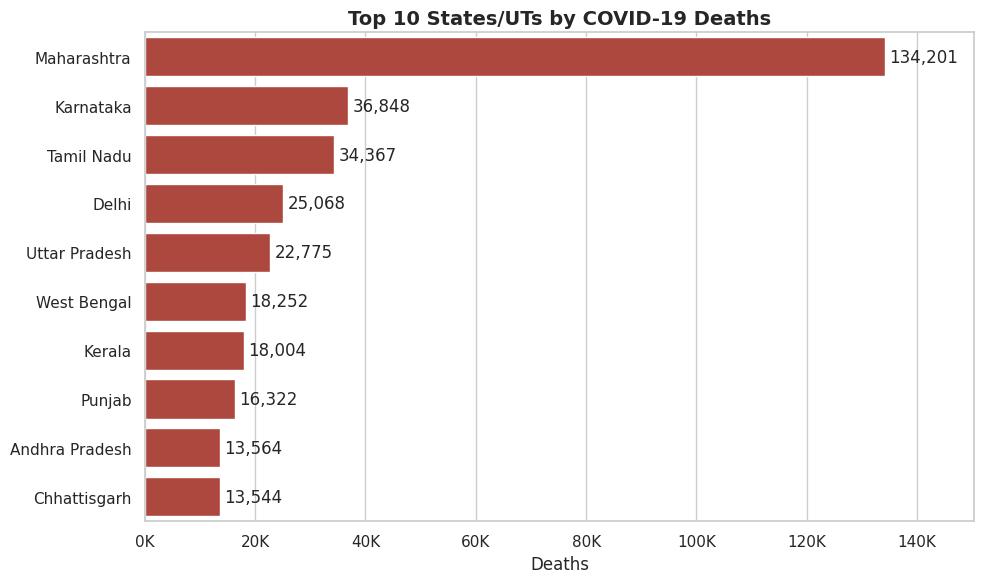

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_deaths, y="State", x="Deaths", color="#c0392b", ax=ax)

ax.set_title("Top 10 States/UTs by COVID-19 Deaths", fontsize=14, weight="bold")
ax.set_xlabel("Deaths")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.bar_label(ax.containers[0], labels=[f"{v:,}" for v in top_deaths["Deaths"]], padding=3)
ax.set_xlim(0, top_deaths["Deaths"].max() * 1.12)

plt.tight_layout()
plt.show()

## 8. Recovery rate vs death rate

If we draw a bar chart with *Death Rate* on x and *Recovery Rate* on y, which is not meaningful for a bar plot. A scatter plot of the ten most-affected states shows the relationship properly: the bubble size reflects total confirmed cases.

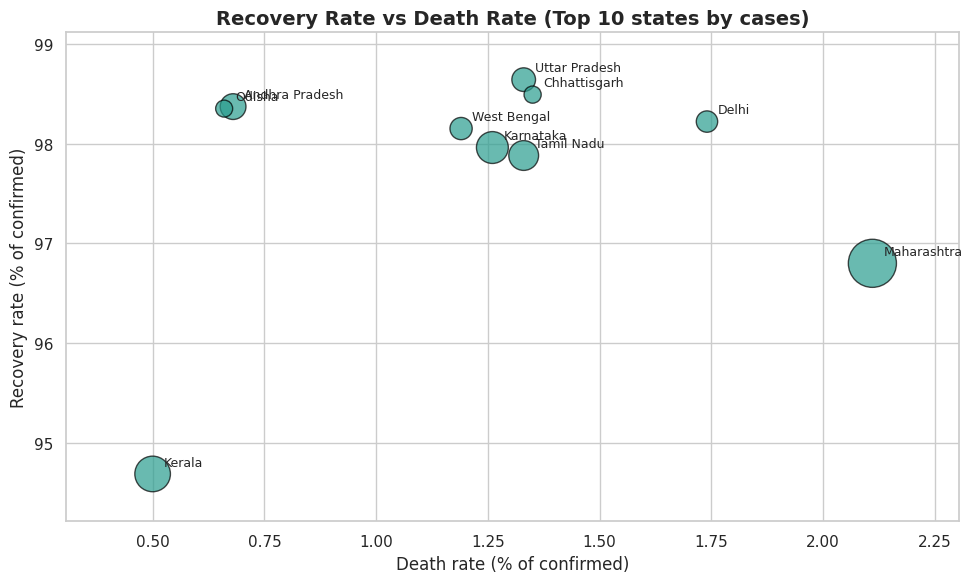

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=top10, x="Death_Rate", y="Recovery_Rate",
    size="Confirmed", sizes=(150, 1200), color="#2a9d8f",
    alpha=0.7, edgecolor="black", legend=False, ax=ax,
)
for _, r in top10.iterrows():
    ax.annotate(r["State"], (r["Death_Rate"], r["Recovery_Rate"]),
                xytext=(8, 6), textcoords="offset points", fontsize=9)

ax.set_title("Recovery Rate vs Death Rate (Top 10 states by cases)",
             fontsize=14, weight="bold")
ax.set_xlabel("Death rate (% of confirmed)")
ax.set_ylabel("Recovery rate (% of confirmed)")
ax.margins(0.12)

plt.tight_layout()
plt.show()

## 9. National trend over time

In [30]:
# Pivot to a state x date grid; forward-fill so a state missing on a given day
# keeps its last cumulative value (otherwise national totals would dip artificially).
all_dates = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")

def national_series(column):
    return (df.pivot(index="Date", columns="State", values=column)
              .reindex(all_dates)
              .ffill()
              .fillna(0)
              .sum(axis=1))

national = pd.DataFrame({
    "Confirmed": national_series("Confirmed"),
    "Deaths":    national_series("Deaths"),
    "Recovered": national_series("Recovered"),
})
national["Active"] = (national["Confirmed"] - national["Deaths"] - national["Recovered"])
national["New_Cases"] = national["Confirmed"].diff().clip(lower=0)
national["New_Cases_7d_Avg"] = national["New_Cases"].rolling(7).mean()
national.index.name = "Date"

national.tail()

,Confirmed,Deaths,Recovered,Active,New_Cases,New_Cases_7d_Avg
Date,,,,,,
2021-08-07,"32,099,901.00","430,878.00","31,255,901.00","413,122.00","38,628.00","40,198.86"
2021-08-08,"32,138,971.00","431,369.00","31,299,811.00","407,791.00","39,070.00","39,804.43"
2021-08-09,"32,174,470.00","431,816.00","31,339,497.00","403,157.00","35,499.00","39,142.29"
2021-08-10,"32,202,674.00","432,189.00","31,381,008.00","389,477.00","28,204.00","38,807.29"
2021-08-11,"32,241,027.00","432,686.00","31,421,021.00","387,320.00","38,353.00","38,197.00"


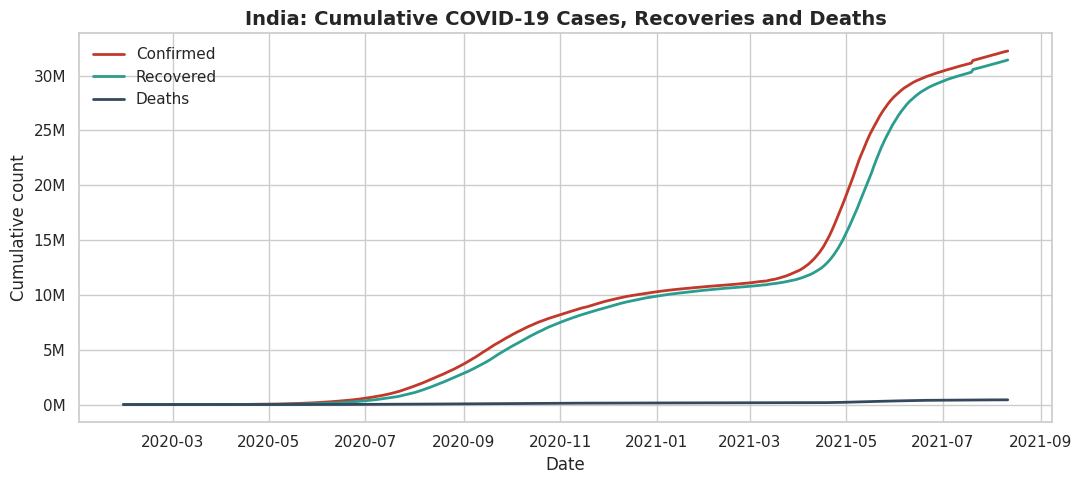

In [31]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national.index, national["Confirmed"], color="#c0392b", lw=2, label="Confirmed")
ax.plot(national.index, national["Recovered"], color="#2a9d8f", lw=2, label="Recovered")
ax.plot(national.index, national["Deaths"], color="#34495e", lw=2, label="Deaths")

ax.set_title("India: Cumulative COVID-19 Cases, Recoveries and Deaths",
             fontsize=14, weight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

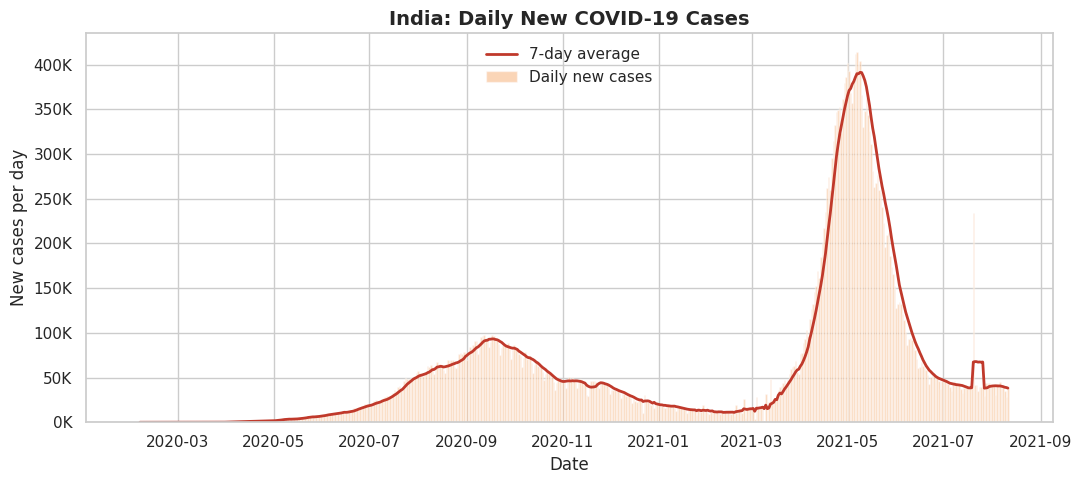

In [32]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(national.index, national["New_Cases"], color="#f4a261", alpha=0.45, width=1, label="Daily new cases")
ax.plot(national.index, national["New_Cases_7d_Avg"], color="#c0392b", lw=2, label="7-day average")

ax.set_title("India: Daily New COVID-19 Cases", fontsize=14, weight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("New cases per day")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [33]:
peak_day = national["New_Cases_7d_Avg"].idxmax()
print(f"Peak of the 7-day average: {national['New_Cases_7d_Avg'].max():,.0f} cases/day on {peak_day:%d %b %Y}")
print(f"Total confirmed (latest):  {national['Confirmed'].iloc[-1]:,.0f}")
print(f"Total deaths (latest):     {national['Deaths'].iloc[-1]:,.0f}")
print(f"National death rate:       {national['Deaths'].iloc[-1] / national['Confirmed'].iloc[-1] * 100:.2f}%")

Peak of the 7-day average: 391,280 cases/day on 09 May 2021
Total confirmed (latest):  32,241,027
Total deaths (latest):     432,686
National death rate:       1.34%
